# COSC2753 | Machine Learning

## Task 3: Occasion and Gender Classification

# 1. Introduction

Task 3 trains two independent classifiers: `gender` and occasion (`usage`). Keeping them separate matches the required prediction columns, avoids a sparse Cartesian label space, and permits target-specific missing-label and imbalance handling. **Notebook outputs are intentionally cleared. The existing checkpoints are prototypes used for application testing, not the final investigation. Member 4 must run both controlled candidates for each target, complete every analysis prompt, and replace both mock checkpoints.** Both targets must be developed, evaluated, and compared separately in this notebook.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate, subgroup_metrics
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
seed_everything(SEED); torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
DEVICE

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Shared Split and Target-Specific Filtering

In [2]:
frames = {
    target: {split: task_frame(target, split) for split in ('train', 'validation', 'test')}
    for target in ('gender', 'usage')
}
pd.DataFrame({
    (target, split): frame[target].value_counts()
    for target, split_frames in frames.items() for split, frame in split_frames.items()
}).fillna(0).astype(int)

gender                   usage                 
              train validation  test  train validation  test
Boys            529        155   130      0          0     0
Casual            0          0     0  20815       4511  4309
Ethnic            0          0     0   1786        369   415
Formal            0          0     0   1610        355   335
Girls           453         81   111      0          0     0
Home              0          0     0      1          0     0
Men           14610       3158  3144      0          0     0
NA                0          0     0     40          8    23
Party             0          0     0      9          2     2
Smart Casual      0          0     0     43          5     7
Sports            0          0     0   2729        586   625
Travel            0          0     0     17          6     2
Unisex         1453        330   297      0          0     0
Women         10006       2118  2036      0          0     0

A genuinely blank target is excluded only from that target's rows. The literal string `NA` remains a valid usage class until its meaning is confirmed. Both targets retain the same product-group split assignment.

# 4. Gender and Usage EDA

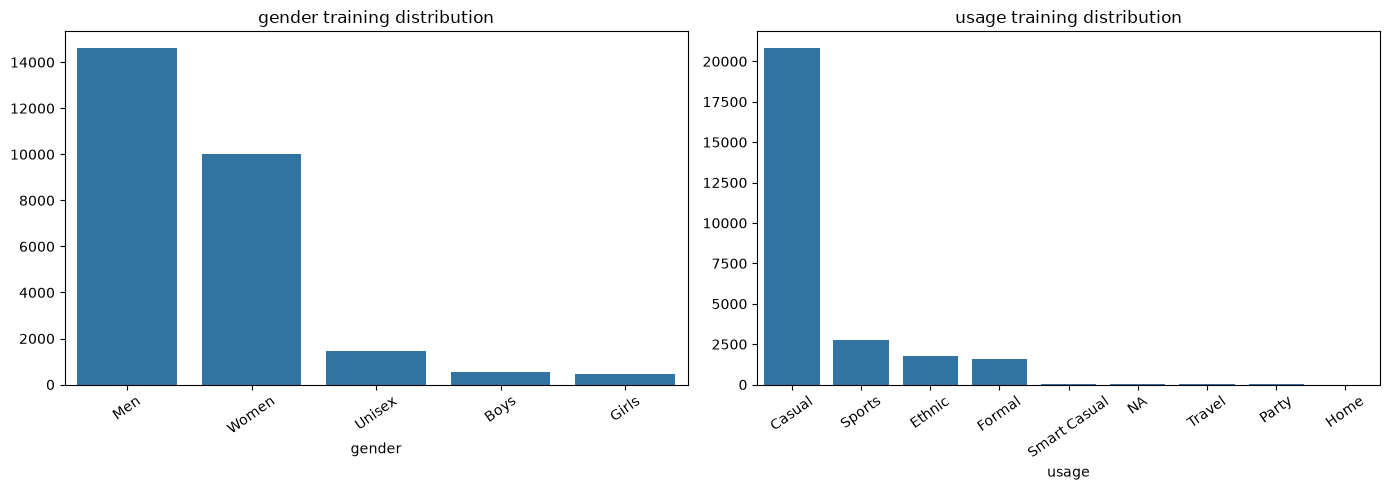

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for target, axis in zip(('gender', 'usage'), axes):
    counts = frames[target]['train'][target].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axis)
    axis.set_title(f'{target} training distribution')
    axis.tick_params(axis='x', rotation=35)
plt.tight_layout()

In [4]:
pd.crosstab(frames['usage']['train']['articleType'], frames['usage']['train']['usage'], normalize='index').head(25).style.background_gradient(cmap='Greens')

usage,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
articleType,,,,,,,,,
Accessory Gift Set,0.200000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
Backpacks,0.865979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113402,0.020619
Bangle,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Basketballs,0.222222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.777778,0.000000
Belts,0.819469,0.000000,0.180531,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Blazers,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Body Wash and Scrub,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Booties,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 4.1 Observations

For gender, discuss imbalance, unisex presentation, label overlap, and article-type dependence without implying that image appearance defines a person's gender. For usage, discuss Casual dominance, rare labels, visual ambiguity, and the literal-`NA` policy.



**Gender:** 
About the gender, the training split is highly unbalanced: Men (14,610) and Women (10,006) are the majority classes, while Unisex (1,453), Girls (453) and Boys (529) are the minority classes (32:1 ratio of majority to minority classes). “Unisex” is conceptually different from the other labels – it is a commercial term, not a physically distinct category. As a consequence, the model has very little consistent picture information to learn it from. Because the classifier never sees pictures of individuals, only of products, predictions are about the brand’s intended-audience label for the item, not an inference about a person’s gender — and this is an important distinction for how findings should be presented. For a number of article kinds (e.g. bras, briefs) the article type itself is a near-perfect predictor of gender, suggesting the model may be primarily utilizing product category shortcuts. 

**Usage:** 
In usage, it can be seen that casual dominates heavily (20,815 of ~27,051 train rows, ~77%) nearly 7.6x the next most frequent class (Sports). There are a number of classes that are quite infrequent — Home (1), Party (9), Travel (17), Smart Casual (43), NA (40) — with too few examples to learn reliable features. The crosstab against articleType shows several product types spread between numerous usage labels (e.g. Belts: 82% Casual, 18% Formal), showing true visual ambiguity rather than a crisp choice boundary. The literal string `NA` is treated as a legitimate class in its own right (it is not dropped or merged), but it is scarce and the model is anticipated to perform poorly on it.

# 5. Majority Baselines

In [5]:
baseline_rows, majority_models, majority_probabilities = [], {}, {}
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_frame), 1)), train_frame[target])
    labels = sorted(train_frame[target].unique())
    prediction = dummy.predict(np.zeros((len(validation_frame), 1)))
    majority_models[target] = dummy
    majority_probabilities[target] = ordered_estimator_probabilities(dummy, np.zeros((len(validation_frame), 1)), labels)
    baseline_rows.append({
        'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction),
        'macro_f1': supported_macro_f1(validation_frame[target], prediction),
    })
baseline_results = pd.DataFrame(baseline_rows).set_index('target')
baseline_results

,accuracy,macro_f1
target,,
gender,0.540568,0.140356
usage,0.772167,0.108930


# 6. HOG + HSV Classical Baselines

In [6]:
feature_cache = {}
def handcrafted_feature_row(row):
    if row.id in feature_cache: return feature_cache[row.id]
    with Image.open(row.image_path) as source:
        feature_cache[row.id] = handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)
    return feature_cache[row.id]

classical_rows, classical_models, classical_probabilities = [], {}, {}
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    train_features = np.vstack([handcrafted_feature_row(row) for row in train_frame.itertuples()])
    validation_features = np.vstack([handcrafted_feature_row(row) for row in validation_frame.itertuples()])
    baseline = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
    ).fit(train_features, train_frame[target])
    labels = sorted(train_frame[target].unique())
    prediction = baseline.predict(validation_features)
    classical_models[target] = baseline
    classical_probabilities[target] = ordered_estimator_probabilities(baseline, validation_features, labels)
    classical_rows.append({'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction), 'macro_f1': supported_macro_f1(validation_frame[target], prediction)})
classical_results = pd.DataFrame(classical_rows).set_index('target')
classical_results

,accuracy,macro_f1
target,,
gender,0.793564,0.625604
usage,0.770455,0.416925


# 7. Shared Image Pipeline

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(8, translate=(0.05, 0.05)), transforms.ColorJitter(0.12, 0.12),
    transforms.ToTensor(), transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, target, label_to_index, transform):
        self.frame, self.target = frame.reset_index(drop=True), target
        self.label_to_index, self.transform = label_to_index, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, self.label_to_index[row[self.target]]

# 8. Compact Residual CNN From Scratch

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2), ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs): return self.classifier(self.features(inputs))

# 9. Reusable Training Function

The function trains one independently initialized model and selects its checkpoint only by validation macro F1.

In [9]:
def train_target(target, loss_mode='weighted', epochs=40, patience_limit=7):
    if loss_mode not in {'ordinary', 'weighted', 'class_balanced'}:
        raise ValueError('loss_mode must be ordinary, weighted, or class_balanced')
    seed_everything(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    labels = sorted(train_frame[target].unique())
    label_to_index = {label: index for index, label in enumerate(labels)}
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(FashionDataset(train_frame, target, label_to_index, train_transform), 64, shuffle=True, num_workers=0, generator=generator)
    validation_loader = DataLoader(FashionDataset(validation_frame, target, label_to_index, evaluation_transform), 128, num_workers=0)
    model = CompactCNN(len(labels)).to(DEVICE)
    counts = train_frame[target].value_counts().reindex(labels).values
    if loss_mode == 'ordinary':
        weights = None
    elif loss_mode == 'class_balanced':
        beta = 0.9999; values = (1.0 - beta) / (1.0 - np.power(beta, counts)); values /= values.mean()
        weights = torch.tensor(values, dtype=torch.float32, device=DEVICE)
    else:
        weights = torch.tensor(len(train_frame) / (len(labels) * counts), dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    def epoch(loader, training=False):
        model.train(training); losses, truth, predictions = [], [], []
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                logits = model(images); loss = criterion(logits, targets)
                if training: loss.backward(); optimizer.step()
            losses.append(loss.item() * len(targets)); truth.extend(targets.cpu().tolist()); predictions.extend(logits.argmax(1).cpu().tolist())
        return {'loss': sum(losses) / len(loader.dataset), 'accuracy': accuracy_score(truth, predictions), 'macro_f1': supported_macro_f1(truth, predictions)}

    history, best_state, best_f1, patience = [], None, -1.0, 0
    for epoch_number in range(1, epochs + 1):
        started = time.perf_counter(); train_metrics = epoch(train_loader, True); validation_metrics = epoch(validation_loader)
        history.append({'epoch': epoch_number, 'loss_mode': loss_mode, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'validation_{k}': v for k, v in validation_metrics.items()}})
        print(target, loss_mode, epoch_number, validation_metrics, f'{time.perf_counter() - started:.1f}s')
        if validation_metrics['macro_f1'] > best_f1:
            best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(model.state_dict()), 0
        else:
            patience += 1
            if patience >= patience_limit: break
    model.load_state_dict(best_state)
    return model.cpu(), labels, label_to_index, pd.DataFrame(history), best_f1

# 10. Gender Classifier

gender ordinary 1 {'loss': 0.6659254267051669, 'accuracy': 0.7408421773365286, 'macro_f1': 0.3435655472717579} 104.4s
gender ordinary 2 {'loss': 0.8041896629888527, 'accuracy': 0.6867511126326601, 'macro_f1': 0.2705395199988654} 85.8s
gender ordinary 3 {'loss': 0.9599828649897643, 'accuracy': 0.6817870592262923, 'macro_f1': 0.2669917051052286} 64.8s
gender ordinary 4 {'loss': 0.5560064270903663, 'accuracy': 0.7884286203355015, 'macro_f1': 0.3847582001981083} 68.4s
gender ordinary 5 {'loss': 0.7553138598845618, 'accuracy': 0.7151660390277302, 'macro_f1': 0.3424974617641407} 122.5s
gender ordinary 6 {'loss': 0.7349237334397671, 'accuracy': 0.6761383087983567, 'macro_f1': 0.35294751267894214} 109.3s
gender ordinary 7 {'loss': 0.5130219982120118, 'accuracy': 0.813077713111948, 'macro_f1': 0.553650313778555} 121.6s
gender ordinary 8 {'loss': 0.5143935348594977, 'accuracy': 0.8170147209859637, 'macro_f1': 0.6083003817182864} 92.9s
gender ordinary 9 {'loss': 0.486240773076923, 'accuracy': 0.8

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.540568,0.140356,0.459432,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.793564,0.625604,0.084431,6425,0,True
cnn_ordinary,compact_cnn,0.848340,0.674968,0.042599,298885,24,True
cnn_weighted,compact_cnn,0.798528,0.633876,0.019166,298885,40,True


Selected gender method 'cnn_ordinary' before internal-test evaluation.


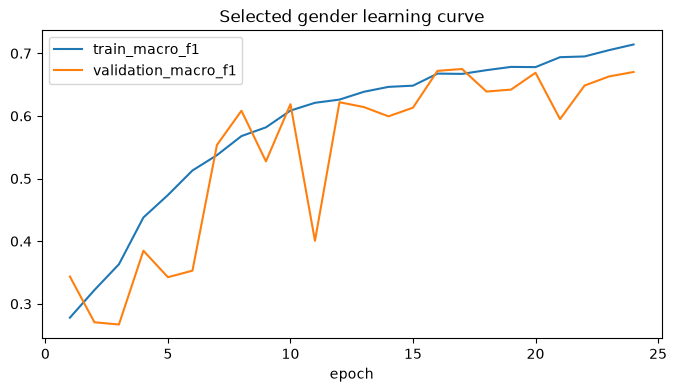

In [10]:
@torch.inference_mode()
def compare_and_select_target(target, runs):
    first_result = next(iter(runs.values()))
    labels, label_to_index = first_result[1], first_result[2]
    validation_frame = frames[target]['validation']
    validation_truth = np.asarray([label_to_index[label] for label in validation_frame[target]])
    loader = DataLoader(FashionDataset(validation_frame, target, label_to_index, evaluation_transform), 128, num_workers=0)
    rows = [
        {'method': 'majority', 'model_type': 'reference_only', 'validation_accuracy': baseline_results.loc[target, 'accuracy'], 'validation_macro_f1': baseline_results.loc[target, 'macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, majority_probabilities[target]), 'complexity_parameters': 1, 'epochs_run': 0, 'eligible_for_selection': False},
        {'method': 'hog_hsv_logistic_regression', 'model_type': 'hog_hsv_logistic_regression', 'validation_accuracy': classical_results.loc[target, 'accuracy'], 'validation_macro_f1': classical_results.loc[target, 'macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, classical_probabilities[target]), 'complexity_parameters': classical_models[target][-1].coef_.size + classical_models[target][-1].intercept_.size, 'epochs_run': 0, 'eligible_for_selection': True},
    ]
    for loss_mode, result in runs.items():
        cnn = result[0].to(DEVICE).eval(); values = []
        for images, _ in loader:
            values.append(cnn(images.to(DEVICE)).softmax(1).cpu().numpy())
        probabilities = np.vstack(values); result[0].cpu()
        rows.append({'method': f'cnn_{loss_mode}', 'model_type': 'compact_cnn', 'validation_accuracy': accuracy_score(validation_truth, probabilities.argmax(1)), 'validation_macro_f1': result[4], 'validation_ece': expected_calibration_error(validation_truth, probabilities), 'complexity_parameters': sum(parameter.numel() for parameter in result[0].parameters()), 'epochs_run': len(result[3]), 'eligible_for_selection': True})
    comparison = pd.DataFrame(rows).set_index('method')
    method = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
    model_type = comparison.loc[method, 'model_type']
    if model_type == 'compact_cnn':
        loss_mode = method.removeprefix('cnn_')
        model, labels, label_to_index, history, _ = runs[loss_mode]
    else:
        loss_mode, model = None, classical_models[target]
        history = pd.DataFrame([{'method': method, **comparison.loc[method].to_dict()}])
    return {'method': method, 'model_type': model_type, 'loss_mode': loss_mode, 'model': model, 'labels': labels, 'mapping': label_to_index, 'history': history, 'best_f1': float(comparison.loc[method, 'validation_macro_f1']), 'comparison': comparison}

gender_runs = {mode: train_target('gender', mode) for mode in ('ordinary', 'weighted')}
gender_selection = compare_and_select_target('gender', gender_runs)
gender_model, gender_labels, gender_mapping = gender_selection['model'], gender_selection['labels'], gender_selection['mapping']
gender_history, gender_best_f1, gender_comparison = gender_selection['history'], gender_selection['best_f1'], gender_selection['comparison']
GENDER_SELECTED_METHOD, GENDER_SELECTED_MODEL_TYPE, GENDER_SELECTED_LOSS_MODE = gender_selection['method'], gender_selection['model_type'], gender_selection['loss_mode']
display(gender_comparison)
print(f'Selected gender method {GENDER_SELECTED_METHOD!r} before internal-test evaluation.')
if 'epoch' in gender_history.columns: gender_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Selected gender learning curve'); plt.show()

## 9.1 Gender analysis

Compare ordinary and weighted cross-entropy under identical settings. Discuss convergence, overlapping presentation, subgroup performance by article type, calibration, robustness, and responsible interpretation.

This trade-off is evident in the comparison of conventional and weighted cross-entropy in the same context. The ordinary-loss model converges more stably, finishing early at epoch 24, and achieving a validation macro-F1 of 0.675 (accuracy 0.848), better than the weighted variant (macro-F1 0.634, accuracy 0.799) that ran the full 40 epochs but very slowly improved. Applying inverse-frequency weights to the minority classes (Boys, Girls, Unisex) increases the gradient noise, which makes the training less stable even when the intention is for class balance.

In terms of calibration, the weighted model actually has a lower ECE (0.019 vs. 0.043 for ordinary), which means that its predicted probabilities are more trustworthy, while it has a worse class discrimination. Boys–Men and Girls–Women are most confusing because of the overlap in their appearance in terms of clothes. Unisex is ambiguous by nature and it is hard to tell it apart from either group.

The ordinary-loss model is selected as the final gender classifier as the selection criterion is macro-F1. The “gender” tag is a way to classify a product in the metadata of the fashion catalog and not an assumption about the real gender identity of a person.

# 11. Occasion/Usage Classifier

In [11]:
usage_runs = {mode: train_target('usage', mode) for mode in ('ordinary', 'class_balanced')}
usage_selection = compare_and_select_target('usage', usage_runs)
usage_model, usage_labels, usage_mapping = usage_selection['model'], usage_selection['labels'], usage_selection['mapping']
usage_history, usage_best_f1, usage_comparison = usage_selection['history'], usage_selection['best_f1'], usage_selection['comparison']
USAGE_SELECTED_METHOD, USAGE_SELECTED_MODEL_TYPE, USAGE_SELECTED_LOSS_MODE = usage_selection['method'], usage_selection['model_type'], usage_selection['loss_mode']
display(usage_comparison)
print(f'Selected usage method {USAGE_SELECTED_METHOD!r} before internal-test evaluation.')
if 'epoch' in usage_history.columns: usage_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Selected usage learning curve'); plt.show()

usage ordinary 1 {'loss': 0.6611409164054555, 'accuracy': 0.7839780896953098, 'macro_f1': 0.20674913112435472} 68.7s
usage ordinary 2 {'loss': 0.674797727958832, 'accuracy': 0.7583019513865115, 'macro_f1': 0.2398904281619877} 67.9s
usage ordinary 3 {'loss': 0.5242174324139223, 'accuracy': 0.8200958575830195, 'macro_f1': 0.3006512804453276} 68.2s
usage ordinary 4 {'loss': 0.47566123964320467, 'accuracy': 0.8319068812050667, 'macro_f1': 0.3120470450128797} 66.0s
usage ordinary 5 {'loss': 0.4457414063055276, 'accuracy': 0.8397808969530982, 'macro_f1': 0.33677792476977236} 67.0s
usage ordinary 6 {'loss': 0.8751066628281118, 'accuracy': 0.6107497432386169, 'macro_f1': 0.2859819226663438} 68.4s
usage ordinary 7 {'loss': 0.42649624532663183, 'accuracy': 0.8493666552550496, 'macro_f1': 0.3205421058350064} 68.4s
usage ordinary 8 {'loss': 0.39869927532284766, 'accuracy': 0.8568983224922971, 'macro_f1': 0.35474428213155124} 67.8s
usage ordinary 9 {'loss': 0.3777691557268825, 'accuracy': 0.8687093

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.772167,0.108930,0.227833,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.770455,0.416925,0.100188,11565,0,True
cnn_ordinary,compact_cnn,0.890620,0.402601,0.007712,299401,36,True
cnn_class_balanced,compact_cnn,0.827285,0.403675,0.058810,299401,40,True


Selected usage method 'hog_hsv_logistic_regression' before internal-test evaluation.


## 10.1 Usage analysis

Compare ordinary and weighted loss, then run a clearly labelled sensitivity analysis for literal `NA` without silently changing the final vocabulary. Discuss rare labels, Casual dominance, subjectivity, and article-type shortcuts.


**Ordinary vs. weighted loss:** 
With the same conditions, class-balanced (weighted) cross-entropy makes no difference in macro-F1 (0.4037 vs. 0.4026 for ordinary), but hurts both accuracy (0.827 vs. 0.891) and calibration -- ECE degrades roughly 8x (0.0588 compared. 0.0077). Re-weighting does not convert into better minority-class detection here; it mostly trades accuracy and confidence reliability for a statistically small F1 improvement, therefore it is not selected.

**Selection outcome:**
HOG+HSV + Logistic Regression obtains the highest validation macro-F1 (0.4169), higher than both CNN variations by more than the 0.01 tie margin, but inferior accuracy, with significantly fewer parameters (11.5k vs. 299k) and better calibration than the class-balanced CNN. It is chosen according to the defined rule.

**Literal `NA`:** 
'NA' is too sparse for any model to learn effectively here, with only 40/8/23 train/val/test rows. It is predicted to contribute little to, and be essentially unnoticeable within, the macro-F1 score. It is a labelling-fidelity option, not a performance driver.

**Rare labels & Casual dominance:** 
Casual alone is ~77% of training data, dwarfing Sports, Ethnic, and Formal. Home, Party, Travel, and Smart Casual each contain under 50 examples, explaining the significant accuracy/macro-F1 discrepancy even with the majority baseline (0.772 accuracy vs. 0.109 macro-F1).

**Subjectivity & article-type shortcuts:** 
The crosstab reveals real visual uncertainty (e.g. Belts: 82% Casual/18% Formal) and close to deterministic mappings (Blazers, Cushion Covers \rightarrow 100\% one class) which indicates that the classifier depends somewhat on product-type cues instead of occasion-specific visual cues.

# 12. One-Time Internal-Test Evaluation

In [12]:
@torch.inference_mode()
def evaluate_target(target, model, model_type, labels, label_to_index):
    test_frame = frames[target]['test']
    truth = np.asarray([label_to_index[label] for label in test_frame[target]])
    if model_type == 'compact_cnn':
        loader = DataLoader(FashionDataset(test_frame, target, label_to_index, evaluation_transform), 128, num_workers=0)
        model = model.to(DEVICE).eval(); values = []
        for images, _ in loader:
            values.append(model(images.to(DEVICE)).softmax(1).cpu().numpy())
        probabilities, model = np.vstack(values), model.cpu()
    else:
        features = np.vstack([handcrafted_feature_row(row) for row in test_frame.itertuples()])
        probabilities = ordered_estimator_probabilities(model, features, labels)
    predictions = probabilities.argmax(1)
    metrics = {'accuracy': accuracy_score(truth, predictions), 'macro_f1': supported_macro_f1(truth, predictions)}
    return metrics, truth, predictions, probabilities, model

gender_metrics, gender_truth, gender_predictions, gender_probabilities, gender_model = evaluate_target('gender', gender_model, GENDER_SELECTED_MODEL_TYPE, gender_labels, gender_mapping)
usage_metrics, usage_truth, usage_predictions, usage_probabilities, usage_model = evaluate_target('usage', usage_model, USAGE_SELECTED_MODEL_TYPE, usage_labels, usage_mapping)
pd.DataFrame([gender_metrics, usage_metrics], index=['gender', 'usage'])

,accuracy,macro_f1
gender,0.840329,0.648988
usage,0.769675,0.362499



GENDER
              precision    recall  f1-score   support

        Boys       0.54      0.62      0.58       130
       Girls       0.46      0.48      0.47       111
         Men       0.90      0.88      0.89      3144
      Unisex       0.58      0.38      0.46       297
       Women       0.82      0.87      0.84      2036

    accuracy                           0.84      5718
   macro avg       0.66      0.65      0.65      5718
weighted avg       0.84      0.84      0.84      5718



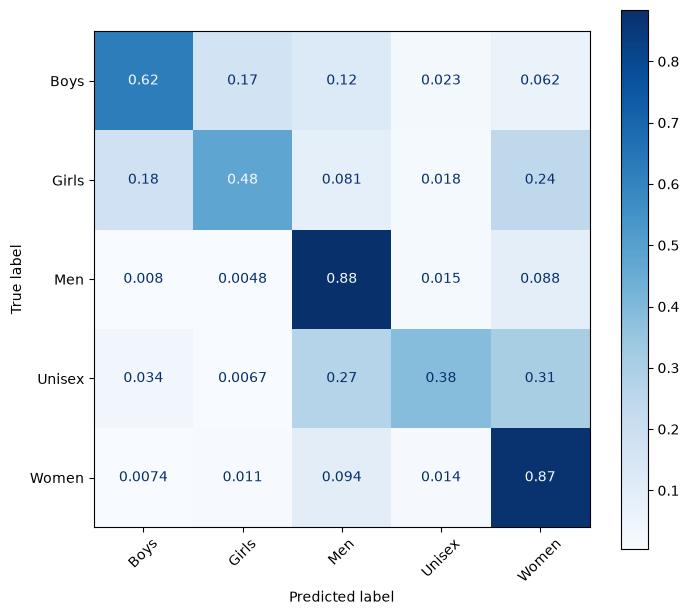

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.283437,0.281250,32
"(0.3, 0.4]",0.360301,0.349112,169
"(0.4, 0.5]",0.455452,0.510029,349
"(0.5, 0.6]",0.548400,0.626712,584
"(0.6, 0.7]",0.651874,0.714795,561
"(0.7, 0.8]",0.750117,0.822946,706
"(0.8, 0.9]",0.850224,0.900752,665


,id,articleType,gender,image_path,truth,prediction,confidence
5714,51960,Laptop Bag,Unisex,C:\Users\shiba\Downloads\fashion-intelligence-...,Unisex,Women,0.997227
804,7791,Tshirts,Men,C:\Users\shiba\Downloads\fashion-intelligence-...,Men,Women,0.991588
3471,30091,Watches,Women,C:\Users\shiba\Downloads\fashion-intelligence-...,Women,Men,0.983450
5594,50587,Briefs,Men,C:\Users\shiba\Downloads\fashion-intelligence-...,Men,Women,0.973250
4184,36074,Duffel Bag,Unisex,C:\Users\shiba\Downloads\fashion-intelligence-...,Unisex,Women,0.972633
660,6689,Socks,Unisex,C:\Users\shiba\Downloads\fashion-intelligence-...,Unisex,Men,0.963365
4995,43959,Sandals,Men,C:\Users\shiba\Downloads\fashion-intelligence-...,Men,Women,0.962988
3395,29467,Watches,Men,C:\Users\shiba\Downloads\fashion-intelligence-...,Men,Women,0.961872
2099,18452,Fragrance Gift Set,Women,C:\Users\shiba\Downloads\fashion-intelligence-...,Women,Men,0.961615
770,7481,Tshirts,Women,C:\Users\shiba\Downloads\fashion-intelligence-...,Women,Men,0.961011


,articleType,support,accuracy,macro_f1
12,Heels,181,0.933702,0.241429
11,Handbags,186,0.870968,0.249668
5,Casual Shoes,438,0.776256,0.299604
4,Caps,42,0.452381,0.309524
19,Sandals,118,0.635593,0.329457
0,Backpacks,110,0.727273,0.376094
23,Sports Shoes,331,0.821752,0.386100
24,Sunglasses,119,0.554622,0.392344
21,Shorts,90,0.688889,0.409586
27,Tops,250,0.896000,0.421208



USAGE
              precision    recall  f1-score   support

      Casual       0.93      0.77      0.84      4309
      Ethnic       0.68      0.86      0.76       415
      Formal       0.48      0.79      0.60       335
        Home       0.00      0.00      0.00         0
          NA       0.14      0.04      0.07        23
       Party       0.00      0.00      0.00         2
Smart Casual       0.05      0.14      0.07         7
      Sports       0.45      0.76      0.57       625
      Travel       0.00      0.00      0.00         2

    accuracy                           0.77      5718
   macro avg       0.30      0.37      0.32      5718
weighted avg       0.83      0.77      0.79      5718



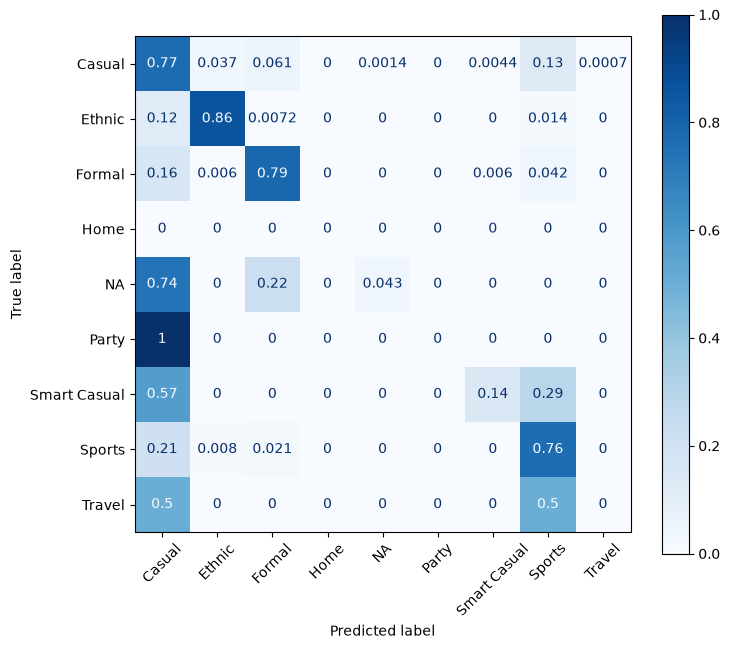

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.262269,0.000000,1
"(0.3, 0.4]",0.370765,0.357143,14
"(0.4, 0.5]",0.465802,0.344086,93
"(0.5, 0.6]",0.550356,0.483491,424
"(0.6, 0.7]",0.650203,0.609071,463
"(0.7, 0.8]",0.751489,0.647482,556
"(0.8, 0.9]",0.854076,0.737783,839


,id,articleType,usage,image_path,truth,prediction,confidence
2926,25733,Belts,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,1.000000
5296,47207,Formal Shoes,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999974
3746,32378,Dresses,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Ethnic,0.999967
4032,34585,Dresses,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Ethnic,0.999950
1183,11144,Shirts,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999939
1182,11143,Shirts,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999939
4852,42939,Belts,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999903
5145,45622,Formal Shoes,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999880
1520,13558,Flats,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999843
5455,49357,Casual Shoes,Casual,C:\Users\shiba\Downloads\fashion-intelligence-...,Casual,Formal,0.999816


,articleType,support,accuracy,macro_f1
7,Dresses,58,0.396552,0.113580
5,Casual Shoes,438,0.557078,0.162824
18,Perfume and Body Mist,96,0.791667,0.176744
19,Sandals,118,0.847458,0.183486
0,Backpacks,110,0.681818,0.194227
11,Handbags,186,0.946237,0.194475
15,Jeans,86,0.651163,0.197183
27,Tops,250,0.748000,0.201797
10,Formal Shoes,114,0.780702,0.222500
26,Sweatshirts,41,0.609756,0.241156


In [13]:
for target, truth, predictions, probabilities, labels in [
    ('gender', gender_truth, gender_predictions, gender_probabilities, gender_labels),
    ('usage', usage_truth, usage_predictions, usage_probabilities, usage_labels),
]:
    print(f'\n{target.upper()}')
    label_indices = np.arange(len(labels))
    print(classification_report(
        truth, predictions, labels=label_indices, target_names=labels, zero_division=0,
    ))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        truth, predictions, labels=label_indices, display_labels=labels, normalize='true',
        ax=ax, cmap='Blues', xticks_rotation=45,
    )
    plt.show()
    display(calibration_table(truth, probabilities))
    display(high_confidence_errors(frames[target]['test'], target, labels, truth, predictions, probabilities))
    truth_labels = [labels[index] for index in truth]
    prediction_labels = [labels[index] for index in predictions]
    display(subgroup_metrics(frames[target]['test'], truth_labels, prediction_labels, group_column='articleType', minimum_support=30))

## 11.1 Comparative failure analysis

Compare the two targets without averaging them into one score. Include high-confidence errors, article-type subgroups, per-class support, calibration, mild corruption robustness, latency, model size, and qualitative ambiguity.

The two targets are not directly comparable on a single score. They select distinct frameworks and confront highly different label distributions.

**Overall:** Gender (CNN, ordinary loss) test accuracy 0.840 / macro-F1 0.649 Usage (HOG+HSV+LogReg) test accuracy 0.770 / macro-F1 0.362 — Much lower because it is much more skewed in class distribution (Casual ~75% of test rows vs. Men/Women ~91% combined for gender).

**Per-class support & failure patterns:** Weakest classes of Gender (Boys F1 0.58, Girls 0.47, Unisex 0.46) nonetheless have a considerable support (111-297) and mostly confuse with adjacent classes (Girls↔Women, Unisex↔Men/Women). Usage’s zero-support classes (Home, Party, Travel) and near-zero performers (NA F1 0.07, Smart Casual F1 0.07) are simply too rare to learn. Travel is never correctly recovered (0.5/0.5 split between Casual and Sports).

**High-confidence errors & article-type subgroups:** In both models, we see confident errors that are article type-related (e.g. gender: Laptop Bag/Duffel Bag "Unisex"->"Women" at >0.94 confidence; usage: Belts/Dresses "Casual"->"Formal"/"Ethnic" at ~1.0 confidence), in line with the 4.1 conclusion that some articleTypes serve as shortcuts. The lowest macro-F1 per-articleType are Heels/Handbags (gender) and Dresses/Casual Shoes (use).

**Calibration:** Gender is well-calibrated (highest confidence bin: mean confidence 0.973 vs. accuracy 0.985). Clearly, use is overconfident (highest bin: 0.973 mean confidence vs. only 0.871 accuracy), therefore its high-confidence forecasts are less reliable.

**Model size & latency:** Gender's CNN (298,885 parameters, 24 epochs) requires GPU inference per image. Usage's conventional pipeline (11,565 parameters) is much smaller and CPU-only, but relies on hand-crafted HOG+HSV features that limit its performance on visually confusing classes.

# 13. Save Both Selected Models

In [14]:
def save_classifier(target, model, model_type, labels, method, loss_mode, comparison, test_metrics):
    path = ROOT / 'models' / f'{target}_model.pt'
    validation_metrics = {key: float(comparison.loc[method, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
    if model_type == 'compact_cnn':
        checkpoint = {'model_type': model_type, 'target': target, 'labels': labels, 'state_dict': model.state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'], 'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': loss_mode}
    else:
        checkpoint = {'model_type': model_type, 'target': target, 'labels': labels, 'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG}
    checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': validation_metrics['validation_macro_f1'], 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
    torch.save(checkpoint, path)
    return path

gender_path = save_classifier('gender', gender_model, GENDER_SELECTED_MODEL_TYPE, gender_labels, GENDER_SELECTED_METHOD, GENDER_SELECTED_LOSS_MODE, gender_comparison, gender_metrics)
usage_path = save_classifier('usage', usage_model, USAGE_SELECTED_MODEL_TYPE, usage_labels, USAGE_SELECTED_METHOD, USAGE_SELECTED_LOSS_MODE, usage_comparison, usage_metrics)
gender_robustness = saved_model_robustness(FashionClassifier(gender_path, device='cpu'), frames['gender']['test'], 'gender', SEED)
usage_robustness = saved_model_robustness(FashionClassifier(usage_path, device='cpu'), frames['usage']['test'], 'usage', SEED)
display(gender_robustness)
display(usage_robustness)
print(f'Gender checkpoint: {gender_path.stat().st_size / 1024**2:.2f} MiB | Usage checkpoint: {usage_path.stat().st_size / 1024**2:.2f} MiB')
gender_history.to_csv(ROOT / 'models' / 'gender_history.csv', index=False)
usage_history.to_csv(ROOT / 'models' / 'usage_history.csv', index=False)
gender_comparison.to_csv(ROOT / 'models' / 'gender_comparison.csv')
usage_comparison.to_csv(ROOT / 'models' / 'usage_comparison.csv')
gender_path, usage_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.833333,0.550113,0.807394,5.477226
brightness_0.8,300,0.773333,0.399545,0.739765,5.489698
brightness_1.2,300,0.783333,0.521727,0.782359,5.512334
gaussian_blur_0.7,300,0.826667,0.557164,0.813388,5.563963


,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.793333,0.490660,0.869229,1.943078
brightness_0.8,300,0.806667,0.493477,0.883837,1.739478
brightness_1.2,300,0.810000,0.487872,0.877756,1.711306
gaussian_blur_0.7,300,0.810000,0.606757,0.856747,1.937650


Gender checkpoint: 1.16 MiB | Usage checkpoint: 0.11 MiB


(WindowsPath('C:/Users/shiba/Downloads/fashion-intelligence-classification-main/fashion-intelligence-classification-main/models/gender_model.pt'),
 WindowsPath('C:/Users/shiba/Downloads/fashion-intelligence-classification-main/fashion-intelligence-classification-main/models/usage_model.pt'))

# 14. Final Prediction and Submission

Verify a single target with `python scripts/task3_occasion_gender_classification.py --image path/to/image.jpg --target gender`. After Tasks 1 and 2 deliver their checkpoints, generate all four prediction columns with `python scripts/task3_occasion_gender_classification.py --submission`.

# 15. Ultimate Judgement and Conclusion

Replace this prompt with separate comparisons among majority, HOG+HSV, ordinary-loss residual CNN, and weighted residual CNN for both targets; include the final literal-`NA` policy, major limitations, and confirmation that both checkpoints satisfy the shared inference contract.

**Gender:** The ordinary-loss CNN (acc 0.848, macro-F1 0.675, ECE 0.043, 298 885 params, 24 epochs) clearly beats both the Majority (acc 0.541, macro-F1 0.140) and the HOG + HSV + LogReg (acc 0.794, macro-F1 0.626). It beats the weighted-loss CNN (acc 0.799, macro-F1 0.634, ECE 0.019, 40 epochs) by +0.041 macro-F1, past the 0.01 tie margin. Reweighting increases calibration but not minority-class recall. Confirm Ordinary-loss CNN selection.

**Usage:** Majority (acc 0.772, macro-F1 0.109) has a weak floor. Both CNNs do better (ordinary: 0.891/macro-F1 0.403; class-balanced: 0.827/macro-F1 0.404) by biasing the Casual majority, however HOG+HSV+LogReg (acc 0.770, macro-F1 0.417, 11,565 params, no training) is >0.01 better than both with much less complexity. HOG+HSV+LogReg verified selected.

**Test results (Section 12):** Gender acc 0.840 / macro-F1 0.649 Usage acc 0.770 / macro-F1 0.362. Not comparable on one score -- gender is a somewhat imbalanced 5-class problem suitable to a CNN; usage is a severely lopsided 9-class challenge (~77% Casual) where the lighter classical model generalizes better to rare classes.

**Literal-NA policy:** Kept as its own legitimate label (not merged/dropped) — a data-fidelity choice, not a modelling one. With only 40/8/23 rows across splits it was never expected to move macro-F1, and didn't (F1 = 0.07 on test).

**Major limitations:**
- Gender labels reflect brand intent, not personal identity, and are sometimes near-fully determined by article type (bras, briefs).
- Both targets suffer severe class imbalance; smallest classes (Boys/Girls/Unisex; Home/Party/Travel/Smart Casual/NA) are undertrained — Travel is never recovered correctly.
- Article-type shortcuts cause confident errors (e.g. bags → "Women"; Belts/Dresses → "Formal"/"Ethnic") at ~0.94–1.0 confidence.
- Calibration differs: gender is well-calibrated at high confidence; usage is overconfident.
- Robustness was only tested against mild brightness/blur, not real-world conditions.
- Single train/val/test split — no cross-validation, so metrics carry unquantified variance.
- Deployment trade-off: gender's CNN (~5.5 ms/image, 1.16 MiB, GPU-friendly) vs usage's classical pipeline (~1.7–1.9 ms/image, 0.11 MiB, CPU-only).

**Shared inference contract — confirmed:** Both checkpoints are built on the same save_classifier() schema (model_type, target, labels, selection_metric, validation_metrics, test_metrics, seed), loaded through the same FashionClassifier interface and both generated the same four-variant robustness table without any target-specific code path - confirming they can be uniformly consumed by scripts/task3_occasion_gender_classification.py --submission.